# ADVANCED PYTHON ANALYSIS

**Author: Gordon Moenga**

# Introduction

The analysis focuses on understanding the structure and quality of the data and identifying important patterns, trends, relationships, and unusual values. Descriptive statistics and visualisations are used to explore transaction activity, customer behaviour, transaction values, and risk related factors. The findings from the EDA provide a foundation for further analysis and support the development of meaningful business insights.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
transactions = pd.read_csv('transactions')
customers = pd.read_csv('customers')

In [26]:
transactions["Transaction_DateTime"] = pd.to_datetime(
    transactions["Transaction_DateTime"]
)

# 1. Validate transaction success and risk review rates

In [10]:
# Do the Week 2 findings still hold when recalculated directly from the transaction data?
total_transactions = len(transactions)

success_rate = (
    transactions.Transaction_Status.eq('Successful').mean() * 100
)

risk_review_rate = (
    transactions.Risk_Review_Flag.eq('Yes').mean() * 100
)

print(f"Total Transactions: {total_transactions:.2f}")
print(f"Transaction Success Rate: {success_rate:.2f}%")
print(f"Risk Review Rate: {risk_review_rate:.2f}%")

Total Transactions: 12000.00
Transaction Success Rate: 90.47%
Risk Review Rate: 19.60%


# 2. Compare average transaction value by customer segment

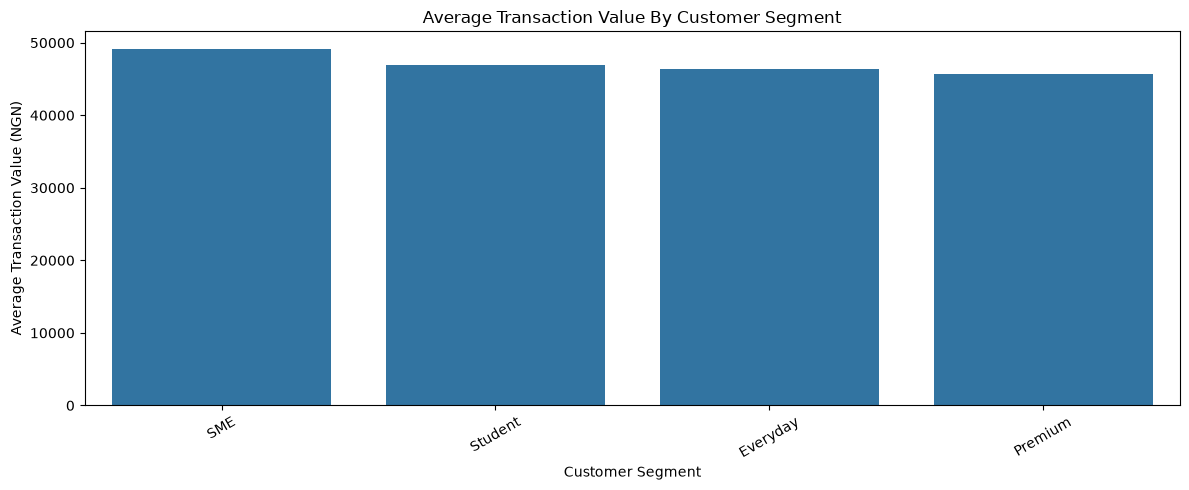

Customer_Segment
SME         49115.69
Student     46953.20
Everyday    46325.11
Premium     45637.95
Name: Amount_NGN, dtype: float64


In [15]:
# Question: Do customers in different segments have different transaction values?
segment_values = (
    transactions.merge(
        customers[['Customer_ID', 'Customer_Segment']],
        on='Customer_ID',
        how='left'
    )
    .groupby('Customer_Segment')['Amount_NGN']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))
sns.barplot(x=segment_values.index, y=segment_values.values)
plt.title("Average Transaction Value By Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Transaction Value (NGN)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(segment_values.round(2))

# 3. Compare transaction values for successful and unsuccessful transactions

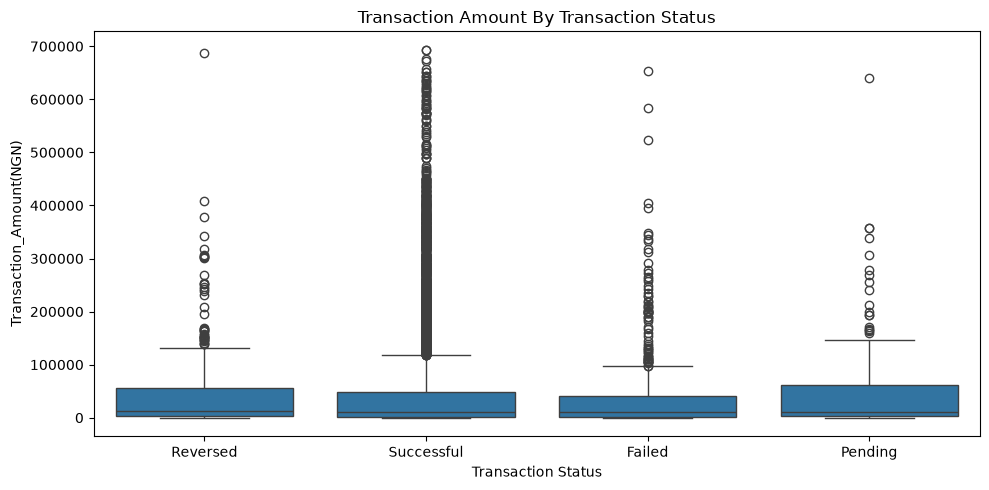

,count,mean,median
Transaction_Status,,,
Failed,630,39405.95,10558.08
Pending,188,49032.15,11495.46
Reversed,326,47932.88,13341.13
Successful,10856,47053.01,10108.32


In [20]:
# Question: Do unsuccessful transactions have a different amount distribution from successful transactions?
plt.figure(figsize=(10,5))
sns.boxplot(
    x=transactions.Transaction_Status,
    y=transactions.Amount_NGN
)

plt.title("Transaction Amount By Transaction Status")
plt.xlabel("Transaction Status")
plt.ylabel("Transaction_Amount(NGN)")
plt.tight_layout()
plt.show()

status_summary = (
    transactions.groupby("Transaction_Status")["Amount_NGN"]
    .agg(['count', 'mean', 'median']).round(2)
)

status_summary

# 4. Investigate high-value transactions by channel

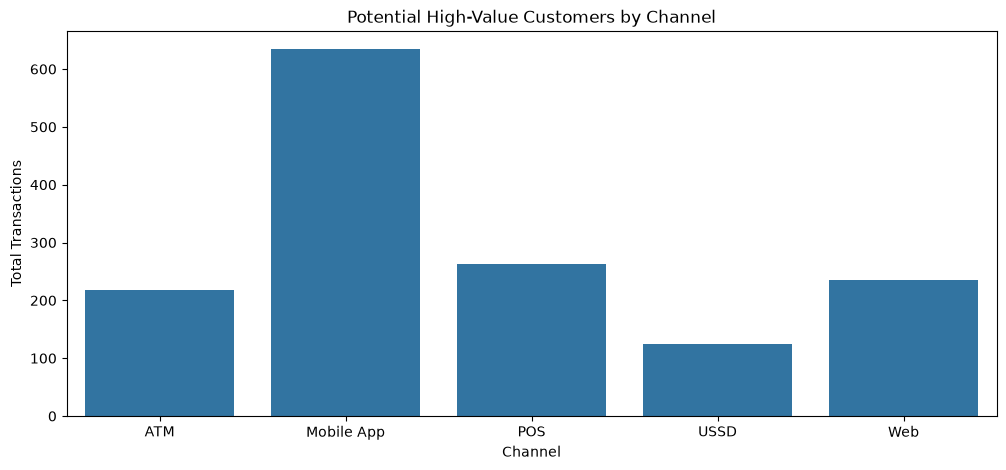

In [24]:
# Question: Which channels account for the potential high-value transactions identified in Week 2?
upper_bound = 117922.8575
high_value = transactions[transactions.Amount_NGN > upper_bound]
high_value_by_channel = (
    high_value.groupby('Channel')
    .agg(
        High_Value_Count=('Transaction_ID', 'count'),
        High_Value_Total =('Amount_NGN', 'sum'),
        Average_Amount=('Amount_NGN', 'mean')
    )
    .sort_values('High_Value_Count', ascending=False)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=high_value_by_channel.sort_index(),
    x='Channel',
    y='High_Value_Count'
)

plt.title("Potential High-Value Customers by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Transactions")
plt.show()

# 5. Analyse monthly transaction success trends

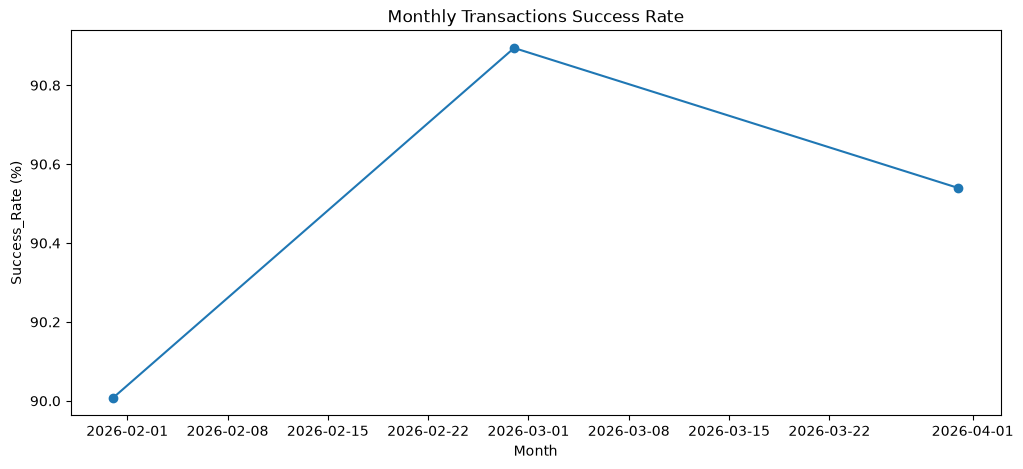

In [30]:
# Question: Has transaction success performance changed from month to month?
monthly_performance = (
    transactions
    .set_index('Transaction_DateTime')
    .resample('ME')
    .agg(
        Total_Transactions=('Transaction_ID', 'count'),
        Successful_Transactions=('Transaction_Status',
                                lambda x: x.eq('Successful').sum()
                               ),
        Total_Value=('Amount_NGN', 'sum')
    )
)

monthly_performance['Success_Rate'] = (
    monthly_performance.Successful_Transactions/
    monthly_performance.Total_Transactions * 100
)

plt.figure(figsize=(12,5))
plt.plot(
    monthly_performance.index,
    monthly_performance.Success_Rate,
    marker='o'
)
plt.title("Monthly Transactions Success Rate")
plt.xlabel("Month")
plt.ylabel("Success_Rate (%)")
plt.show()

# 6. Compare risk review rates across transaction types and international status

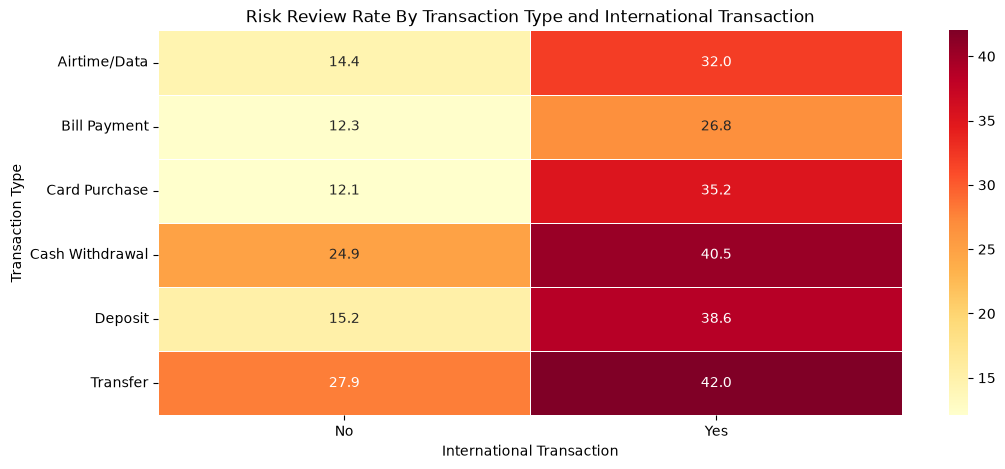

In [39]:
# Question: Are risk review patterns different for international and domestic transactions within each transaction type?
risk_comparison = (
    transactions.pivot_table(
        values = 'Risk_Review_Flag',
        index = 'Transaction_Type',
        columns = 'International_Transaction',
        aggfunc = lambda x: x.eq('Yes').mean() * 100
            )
)

plt.figure(figsize=(12,5))
sns.heatmap(
    risk_comparison,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Risk Review Rate By Transaction Type and International Transaction")
plt.xlabel("International Transaction")
plt.ylabel("Transaction Type")
plt.show()

In [42]:
risk_comparison.round(2)

International_Transaction,No,Yes
Transaction_Type,,
Airtime/Data,14.45,32.00
Bill Payment,12.26,26.79
Card Purchase,12.07,35.20
Cash Withdrawal,24.86,40.48
Deposit,15.18,38.60
Transfer,27.89,42.00
